# Did conversion actually move?

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/proportion-test/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/proportion-test/demo.ipynb)

Four tests get run on a 2x2 conversion table - the z-test, chi-square (with or without Yates),
Fisher's exact and Barnard's exact - and reported as though they were interchangeable. They are not.
For fixed arm sizes there are only `(n1+1)(n2+1)` possible tables, so every test's false-alarm rate
and power can be computed **exactly**. No simulation anywhere in this notebook.

1. Calibration - two of the four tests are the same test
2. Exact size - who runs hot, who runs cold
3. The expected-count-below-5 rule, scored
4. Exact power - what Fisher's caution costs
5. One table, four answers
6. Try your own

## The engine

Extracted from `proportion.py` at build time, character for character.

In [1]:
from __future__ import annotations

from typing import Dict, List, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

ALPHA = 0.05


TESTS = ("z", "yates", "fisher", "barnard")


LABEL = {"z": "z-test = chi-square", "yates": "chi-square + Yates",
         "fisher": "Fisher exact", "barnard": "Barnard exact"}


BAND_LO, BAND_HI = 0.045, 0.055


NUISANCE = np.linspace(0.0005, 0.9995, 400)


def verdict(size: float) -> str:
    if size > BAND_HI:
        return "INFLATED"
    if size < BAND_LO:
        return "CONSERVATIVE"
    return "ok"


def grid(n1: int, n2: int) -> Tuple[np.ndarray, np.ndarray]:
    return np.arange(n1 + 1)[:, None], np.arange(n2 + 1)[None, :]


def z_stat(n1: int, n2: int) -> np.ndarray:
    """Pooled two-proportion z. Tables with an empty column (0 or all successes) score 0."""
    x1, x2 = grid(n1, n2)
    pool = (x1 + x2) / (n1 + n2)
    se = np.sqrt(pool * (1.0 - pool) * (1.0 / n1 + 1.0 / n2))
    with np.errstate(divide="ignore", invalid="ignore"):
        z = np.where(se > 0, (x1 / n1 - x2 / n2) / np.where(se > 0, se, 1.0), 0.0)
    return z


def p_z(n1: int, n2: int) -> np.ndarray:
    return 2.0 * stats.norm.sf(np.abs(z_stat(n1, n2)))


def chi2_uncorrected(n1: int, n2: int) -> np.ndarray:
    """Pearson's chi-square written from its own formula, NOT from z - so the identity
    z^2 == chi-square is something the tests check rather than something the code assumes."""
    x1, x2 = grid(n1, n2)
    a, b, c, d = x1, n1 - x1, x2, n2 - x2
    n = n1 + n2
    c1, c2 = a + c, b + d
    den = (n1 * n2) * c1 * c2
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(den > 0, n * (a * d - b * c) ** 2 / np.where(den > 0, den, 1), 0.0)


def p_yates(n1: int, n2: int) -> np.ndarray:
    """Chi-square with Yates' correction, matching scipy.chi2_contingency(correction=True):
    each |O - E| is reduced by min(0.5, |O - E|), which for a 2x2 is max(0, |ad - bc| - N/2)."""
    x1, x2 = grid(n1, n2)
    a, b, c, d = x1, n1 - x1, x2, n2 - x2
    n = n1 + n2
    c1, c2 = a + c, b + d
    den = (n1 * n2) * c1 * c2
    num = n * np.maximum(0.0, np.abs(a * d - b * c) - n / 2.0) ** 2
    with np.errstate(divide="ignore", invalid="ignore"):
        chi = np.where(den > 0, num / np.where(den > 0, den, 1), 0.0)
    return stats.chi2.sf(chi, 1)


def p_fisher(n1: int, n2: int) -> np.ndarray:
    """Two-sided Fisher, vectorised by margin. Same rule as scipy: sum every table on that margin
    whose hypergeometric probability is <= the observed one, with scipy's 1e-7 relative slack."""
    out = np.ones((n1 + 1, n2 + 1))
    for m in range(n1 + n2 + 1):
        lo, hi = max(0, m - n2), min(n1, m)
        k = np.arange(lo, hi + 1)
        pmf = stats.hypergeom.pmf(k, n1 + n2, n1, m)
        # p(k) = sum of pmf over tables no more likely than k
        order = np.sort(pmf)
        csum = np.cumsum(order)
        idx = np.searchsorted(order, pmf * (1 + 1e-7), side="right") - 1
        out[k, m - k] = np.minimum(1.0, csum[idx])
    return out


def p_barnard(n1: int, n2: int, nuisance: np.ndarray = NUISANCE) -> np.ndarray:
    """Barnard's unconditional exact test with the pooled z statistic (scipy's default).

    p(table) = sup over pi of P(|Z| >= |Z_obs| ; both arms at rate pi). Tables are sorted by |Z|
    once; for each pi the tail probability of every table is one cumulative sum, with ties
    resolved so that tables sharing a statistic share a p-value.
    """
    t = np.abs(z_stat(n1, n2)).ravel()
    order = np.argsort(-t, kind="stable")
    ts = t[order]
    # last index of each tie group, so the tail includes every table at least as extreme
    last = np.searchsorted(-ts, -ts, side="right") - 1
    x1, x2 = grid(n1, n2)
    best = np.zeros(t.size)
    for pi in nuisance:
        w = (stats.binom.pmf(x1, n1, pi) * stats.binom.pmf(x2, n2, pi)).ravel()[order]
        tail = np.cumsum(w)[last]
        best = np.maximum(best, tail)
    out = np.empty(t.size)
    out[order] = np.minimum(best, 1.0)
    return out.reshape(n1 + 1, n2 + 1)


def all_pvalues(n1: int, n2: int) -> Dict[str, np.ndarray]:
    return {"z": p_z(n1, n2), "yates": p_yates(n1, n2),
            "fisher": p_fisher(n1, n2), "barnard": p_barnard(n1, n2)}


def weights(n1: int, n2: int, p1: float, p2: float) -> np.ndarray:
    x1, x2 = grid(n1, n2)
    return stats.binom.pmf(x1, n1, p1) * stats.binom.pmf(x2, n2, p2)


def rate(reject: np.ndarray, n1: int, n2: int, p1: float, p2: float) -> float:
    """Exact probability of landing in a rejection region. No replicates, no seed."""
    return float(weights(n1, n2, p1, p2)[reject].sum())


def size_curve(pv: np.ndarray, n1: int, n2: int, ps: Sequence[float],
               alpha: float = ALPHA) -> np.ndarray:
    """Exact Type I rate at each common true rate p. The test's SIZE is the max of this curve."""
    rej = pv < alpha
    return np.array([rate(rej, n1, n2, p, p) for p in ps])


def min_expected(n1: int, n2: int, p: float) -> float:
    """Smallest expected cell count under the null at true rate p - the quantity the
    'use Fisher when an expected count is below 5' rule is written in."""
    return float(min(n1, n2) * min(p, 1.0 - p))


SIZE_PS: List[float] = [round(float(p), 3) for p in np.linspace(0.01, 0.5, 50)]


SIZE_DESIGNS: List[Tuple[int, int]] = [
    (10, 10), (20, 20), (30, 30), (50, 50), (100, 100), (200, 200),
    (20, 80), (10, 100), (50, 200),
]


POWER_DESIGNS: List[Tuple[float, float, int, int]] = [
    (0.10, 0.30, 30, 30),
    (0.10, 0.20, 100, 100),
    (0.10, 0.20, 200, 200),
    (0.05, 0.12, 200, 200),
    (0.02, 0.08, 200, 200),
    (0.30, 0.45, 100, 100),
    (0.10, 0.25, 20, 80),
]


LATTICE_N = 20   # the design drawn as a rejection-region map in the chart


def size_table(designs: Sequence[Tuple[int, int]] = tuple(SIZE_DESIGNS),
               ps: Sequence[float] = tuple(SIZE_PS)) -> List[Dict[str, object]]:
    rows: List[Dict[str, object]] = []
    for n1, n2 in designs:
        pv = all_pvalues(n1, n2)
        row: Dict[str, object] = {"n1": n1, "n2": n2}
        for t in TESTS:
            curve = size_curve(pv[t], n1, n2, ps)
            j = int(np.argmax(curve))
            row[t] = float(curve[j])
            row[t + "_at_p"] = float(ps[j])
            row[t + "_mean"] = float(curve.mean())
            row[t + "_curve"] = [float(v) for v in curve]
            row[t + "_verdict"] = verdict(float(curve[j]))
        rows.append(row)
    return rows


def power_table(designs: Sequence[Tuple[float, float, int, int]] = tuple(POWER_DESIGNS)
                ) -> List[Dict[str, object]]:
    rows: List[Dict[str, object]] = []
    for p1, p2, n1, n2 in designs:
        pv = all_pvalues(n1, n2)
        row: Dict[str, object] = {"p1": p1, "p2": p2, "n1": n1, "n2": n2}
        for t in TESTS:
            row[t] = rate(pv[t] < ALPHA, n1, n2, p1, p2)
        # the disagreement a reader actually meets: z says moved, Fisher says not
        row["z_not_fisher"] = rate((pv["z"] < ALPHA) & (pv["fisher"] >= ALPHA), n1, n2, p1, p2)
        row["barnard_not_fisher"] = rate((pv["barnard"] < ALPHA) & (pv["fisher"] >= ALPHA),
                                         n1, n2, p1, p2)
        rows.append(row)
    return rows


def expected_count_rule(size_rows: Sequence[Dict[str, object]],
                        ps: Sequence[float] = tuple(SIZE_PS)) -> Dict[str, object]:
    """Score the rule 'the z / chi-square test is fine when every expected count is >= 5' as a
    classifier, cell by cell, against the z-test's EXACT Type I rate at that cell."""
    safe_but_broken, unsafe_but_fine, safe_ok, unsafe_broken = [], [], 0, 0
    for r in size_rows:
        n1, n2 = int(r["n1"]), int(r["n2"])
        for p, s in zip(ps, r["z_curve"]):
            e = min_expected(n1, n2, p)
            broken = s > BAND_HI
            cell = {"n1": n1, "n2": n2, "p": p, "min_expected": e, "size": s}
            if e >= 5 and broken:
                safe_but_broken.append(cell)
            elif e < 5 and not broken:
                unsafe_but_fine.append(cell)
            elif e >= 5:
                safe_ok += 1
            else:
                unsafe_broken += 1
    return {"safe_but_broken": safe_but_broken, "unsafe_but_fine": unsafe_but_fine,
            "safe_ok": safe_ok, "unsafe_broken": unsafe_broken}


def exemplar(n: int = LATTICE_N) -> Dict[str, object]:
    """One table on which the four tests give the four answers a reader would meet.

    Chosen deterministically: the table with the smallest x1 + x2 (then smallest x1) where the
    z-test rejects and Fisher's p is above 0.05. Never hand-picked.
    """
    pv = all_pvalues(n, n)
    cand = [(i + j, i, j) for i in range(n + 1) for j in range(i + 1, n + 1)
            if pv["z"][i, j] < ALPHA and pv["fisher"][i, j] >= ALPHA]
    _, i, j = min(cand)
    return {"n": n, "x1": i, "x2": j, **{t: float(pv[t][i, j]) for t in TESTS}}


def lattice_regions(n: int = LATTICE_N) -> Dict[str, object]:
    """For every table in an n/n design, which of z / Barnard / Fisher rejects. Nesting is
    MEASURED, not assumed: `other` counts any table that breaks z > Barnard > Fisher."""
    pv = all_pvalues(n, n)
    z, b, f = pv["z"] < ALPHA, pv["barnard"] < ALPHA, pv["fisher"] < ALPHA
    code = np.full((n + 1, n + 1), 0)
    code[z & ~b & ~f] = 1
    code[z & b & ~f] = 2
    code[z & b & f] = 3
    other = ~((code > 0) | (~z & ~b & ~f))
    code[other] = 4
    return {"n": n, "code": code.tolist(), "counts": {
        "none": int((code == 0).sum()), "z_only": int((code == 1).sum()),
        "z_barnard": int((code == 2).sum()), "all": int((code == 3).sum()),
        "other": int((code == 4).sum())}}

print('engine loaded')

engine loaded


## 1. Calibration

Every p-value is checked against scipy first. And one identity: the pooled z statistic squared is
Pearson's chi-square. Written from two different formulas, they agree to machine precision - so
"we ran a z-test and a chi-square and they agreed" is one test run twice.

In [2]:
n1, n2 = 15, 12
pv = all_pvalues(n1, n2)
print("max |z^2 - chi2|     ", f"{np.abs(z_stat(n1, n2) ** 2 - chi2_uncorrected(n1, n2)).max():.1e}")
print("max |Fisher - scipy| ", f"{max(abs(stats.fisher_exact([[i, n1-i], [j, n2-j]])[1] - pv['fisher'][i, j]) for i in range(n1+1) for j in range(n2+1)):.1e}")
ref = stats.barnard_exact(np.array([[5, 6], [10, 6]])).pvalue
print("Barnard 5/15 vs 6/12  ", f"ours {pv['barnard'][5, 6]:.6f}  scipy {ref:.6f}  (grid = lower bound)")

max |z^2 - chi2|      1.1e-14
max |Fisher - scipy|  2.2e-16
Barnard 5/15 vs 6/12   ours 0.513682  scipy 0.513790  (grid = lower bound)


## 2. Exact size

Both arms at the same true rate, so every rejection is a false alarm. A test's size is its WORST
false-alarm rate over true rates 0.01 to 0.50. INFLATED above 0.055, CONSERVATIVE below 0.045.

In [3]:
size_rows = size_table()
print("   n1/n2    " + "".join(f"{LABEL[t]:>22}" for t in TESTS))
for r in size_rows:
    print(f"  {r['n1']:>4}/{r['n2']:<4}" + "".join(f"{r[t]:>13.4f} {r[t + '_verdict'][:5]:<8}" for t in TESTS))

   n1/n2       z-test = chi-square    chi-square + Yates          Fisher exact         Barnard exact
    10/10         0.0422 CONSE          0.0128 CONSE          0.0128 CONSE          0.0422 CONSE   
    20/20         0.0534 ok             0.0215 CONSE          0.0253 CONSE          0.0498 ok      
    30/30         0.0553 INFLA          0.0274 CONSE          0.0274 CONSE          0.0469 ok      
    50/50         0.0569 INFLA          0.0352 CONSE          0.0352 CONSE          0.0488 ok      
   100/100        0.0560 INFLA          0.0400 CONSE          0.0400 CONSE          0.0496 ok      
   200/200        0.0512 ok             0.0402 CONSE          0.0402 CONSE          0.0496 ok      
    20/80         0.0877 INFLA          0.0268 CONSE          0.0428 CONSE          0.0462 ok      
    10/100        0.0826 INFLA          0.0214 CONSE          0.0400 CONSE          0.0452 ok      
    50/200        0.0813 INFLA          0.0338 CONSE          0.0420 CONSE          0.0461 ok      

The z-test runs hot on unbalanced arms (a 20 vs 80 split reaches 0.088 - 1.75x nominal). Fisher is
conservative on **every** design, and Yates lands on Fisher's size exactly on several of them: the
continuity correction does not repair the z-test, it turns it into an approximation of Fisher.
Barnard, which maximises over the unknown common rate, never exceeds 0.05 and is inside the band
on all but the smallest design.

## 3. "Use Fisher when an expected count is below 5"

Score that rule as a classifier against the z-test's exact false-alarm rate, cell by cell.

In [4]:
ecr = expected_count_rule(size_rows)
print("                         z fine   z inflated")
print(f"  rule says safe (>=5)   {ecr['safe_ok']:>6}   {len(ecr['safe_but_broken']):>8}")
print(f"  rule says unsafe (<5)  {len(ecr['unsafe_but_fine']):>6}   {ecr['unsafe_broken']:>8}")
w = max(ecr['safe_but_broken'], key=lambda c: c['size'])
print(f"\nworst cell the rule calls safe: {w['n1']}/{w['n2']} at p={w['p']}, "
      f"min expected {w['min_expected']:.0f}, z false-alarm {w['size']:.4f}")

                         z fine   z inflated
  rule says safe (>=5)      252         12
  rule says unsafe (<5)     174         12

worst cell the rule calls safe: 50/50 at p=0.5, min expected 25, z false-alarm 0.0569


Half the inflated cells sit where every expected count is at least 5 - some at expected counts of
25 and more - and almost everything the rule sends to Fisher was already fine. The z-test's error on
a 2x2 comes from the table lattice being discrete, not only from small counts.

## 4. Exact power

In [5]:
power_rows = power_table()
print("   p1 -> p2    n1/n2    " + "".join(f"{t:>9}" for t in TESTS) + "   Barnard-Fisher")
for r in power_rows:
    print(f"  {r['p1']:.2f} -> {r['p2']:.2f}  {r['n1']:>3}/{r['n2']:<4}"
          + "".join(f"{r[t]:>9.4f}" for t in TESTS) + f"   {r['barnard'] - r['fisher']:+.4f}")

   p1 -> p2    n1/n2            z    yates   fisher  barnard   Barnard-Fisher
  0.10 -> 0.30   30/30     0.4995   0.3716   0.3716   0.4801   +0.1085
  0.10 -> 0.20  100/100    0.5177   0.4246   0.4442   0.5016   +0.0574
  0.10 -> 0.20  200/200    0.8110   0.7681   0.7681   0.7976   +0.0295
  0.05 -> 0.12  200/200    0.7170   0.6601   0.6601   0.7034   +0.0432
  0.02 -> 0.08  200/200    0.8173   0.7506   0.7506   0.8110   +0.0605
  0.30 -> 0.45  100/100    0.5944   0.5349   0.5349   0.5895   +0.0545
  0.10 -> 0.25   20/80     0.2871   0.1436   0.2141   0.2502   +0.0361


Barnard beats Fisher on every design here while holding size - the price of conditioning on both
margins is up to 11 points of power. The z-test's column is higher still, but wherever section 2
flags it INFLATED that lead is not power: an inflated test detects more because it rejects more
of everything.

## 5. One table, four answers

Chosen by rule (the smallest table on 20/20 where z rejects and Fisher does not), then the whole
outcome lattice drawn with each table coloured by which tests reject it.

control 0/20, variant 4/20
  z-test = chi-square    p = 0.0350  moved
  chi-square + Yates     p = 0.1138  not shown
  Fisher exact           p = 0.1060  not shown
  Barnard exact          p = 0.0386  moved


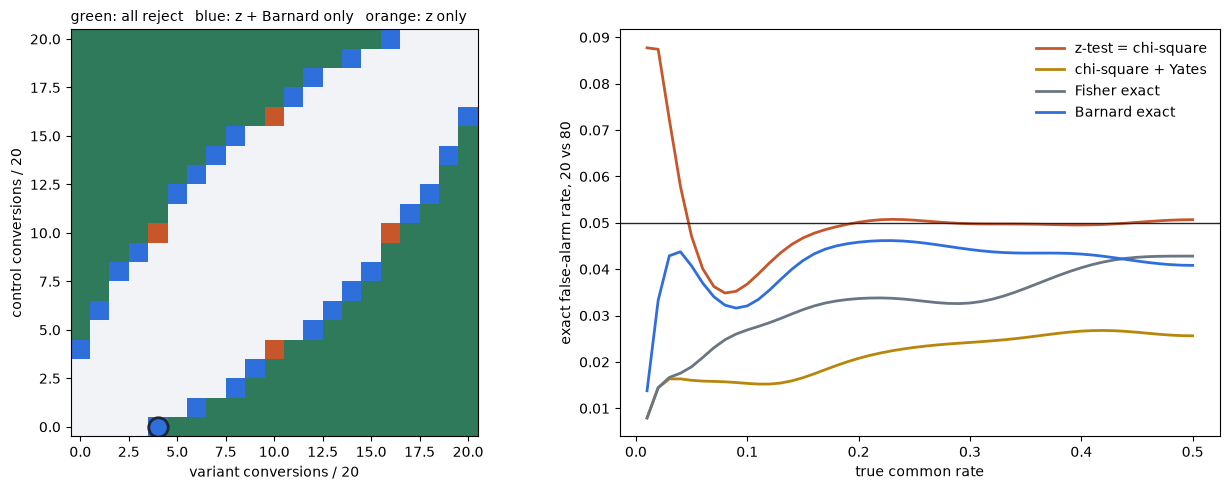

{'none': 199, 'z_only': 4, 'z_barnard': 24, 'all': 214, 'other': 0}


In [6]:
ex = exemplar()
print(f"control {ex['x1']}/20, variant {ex['x2']}/20")
for t in TESTS:
    print(f"  {LABEL[t]:<22} p = {ex[t]:.4f}  {'moved' if ex[t] < ALPHA else 'not shown'}")

lat = lattice_regions()
regions = np.array(lat['code'])
from matplotlib.colors import ListedColormap
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))
a1.imshow(regions, origin="lower", cmap=ListedColormap(["#f1f3f6", "#c8562b", "#2f6fdb", "#2f7a5a", "#000"]),
          vmin=-0.5, vmax=4.5)
a1.plot([ex['x2']], [ex['x1']], "o", ms=14, mfc="none", mec="#1f2733", mew=2)
a1.set_xlabel("variant conversions / 20")
a1.set_ylabel("control conversions / 20")
a1.set_title("green: all reject   blue: z + Barnard only   orange: z only", loc="left", fontsize=10)
row = next(r for r in size_rows if (r['n1'], r['n2']) == (20, 80))
for t, col in zip(TESTS, ["#c8562b", "#b8860b", "#6b7684", "#2f6fdb"]):
    a2.plot(SIZE_PS, row[t + '_curve'], color=col, label=LABEL[t], lw=2)
a2.axhline(0.05, color="#1f2733", lw=1)
a2.set_xlabel("true common rate")
a2.set_ylabel("exact false-alarm rate, 20 vs 80")
a2.legend(frameon=False)
plt.tight_layout()
plt.savefig("notebook_chart.png", dpi=150)
plt.show()
print(lat['counts'])

## Summary

| | |
|---|---|
| **z-test vs chi-square** | the same test - `z^2 = chi2` to 1e-14 |
| **z-test** | inflated on 6 of 9 designs, worst 0.088 on a 20/80 split |
| **Fisher / Yates** | conservative on every design; Yates often has exactly Fisher's size |
| **Barnard** | never above 0.05, and more power than Fisher on 7 of 7 designs (up to +0.109) |
| **Rule of five** | calls 12 inflated cells safe; 94% of cells it sends to Fisher were fine |

For an A/B conversion readout, the defensible default is **Barnard** (or, at large n, the z-test
on a balanced split) - and whichever test is used, report its size at your arm sizes, because the
worst-case false-alarm rate is a property of the design you can compute before launch.

## Try your own

In [7]:
# Your readout: conversions and visitors per arm.
# x1, n1, x2, n2 = 12, 400, 27, 410
# pv = all_pvalues(n1, n2)
# for t in TESTS:
#     size = size_curve(pv[t], n1, n2, SIZE_PS[::5]).max()
#     print(f"{LABEL[t]:<22} p = {pv[t][x1, x2]:.4f}   worst false-alarm at these sizes {size:.4f}")
print("uncomment to explore")

uncomment to explore


---

**Built by Phoebe Fu** - one mini product a day. [Repo](https://github.com/phoebefu6/phoebe-the-builder) ·
[This build](data-science-cookbook/proportion-test)

Streamlit version, where you type in your own counts and see all four tests plus each one's
calibration at your arm sizes:

```bash
pip install -r requirements.txt
streamlit run app.py
```

Sibling builds: [`crosstab-chi2`](../crosstab-chi2) runs one chi-square test well;
[`ci-overlap-fallacy`](../ci-overlap-fallacy) measured exact coverage of four proportion INTERVALS;
[`t-test-variants`](../t-test-variants) did the same disagreement audit for means.